In [9]:
# Cell 1: Imports
from pathlib import Path
import requests
from time import sleep
from urllib.parse import urlencode
import os, re, zipfile
from IPython.display import display, HTML
from io import BytesIO

print("Libraries ready.")


Libraries ready.


In [10]:
# Cell 2: Optional - mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# BASE_SAVE_DIR = Path('/content/drive/MyDrive/ImageDownloader')
# BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)
BASE_SAVE_DIR = Path('/content')  # default working directory in Colab


In [11]:
# Cell 3 - Parameters
from pathlib import Path

TAG = "dog"
MAX_IMAGES = 5
BASE_SAVE_DIR = Path('/content')
SAVE_DIR = BASE_SAVE_DIR / "downloaded_images"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tag={TAG}, Max={MAX_IMAGES}, Save dir={SAVE_DIR}")


Tag=dog, Max=5, Save dir=/content/downloaded_images


In [12]:
# Cell 4- 更健壮的 downloader

import requests, os, re
from time import sleep
from urllib.parse import urlencode
from PIL import Image, UnidentifiedImageError
from io import BytesIO

# Create session with polite headers
session = requests.Session()
session.headers.update({
    "User-Agent": "ImageDownloaderForHomework/1.0 (+https://example.com)",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,image/apng,*/*;q=0.8",
    "Referer": "https://www.flickr.com/"
})

def fetch_flickr_public_feed(tag, timeout=15):
    base = 'https://www.flickr.com/services/feeds/photos_public.gne'
    params = {'format':'json', 'nojsoncallback':'1', 'tags': tag}
    url = base + '?' + urlencode(params)
    print("Fetching feed:", url)
    r = session.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()

def candidate_image_urls(media_url):
    if not media_url:
        return []
    base, ext = os.path.splitext(media_url)
    # try the exact media.m first (it's the one feed provides)
    # then larger candidates
    suffixes = ['_m','_n','_z','_c','_b','_q','_s']
    # create unique list preserving order but ensuring _m is first
    candidates = []
    for suf in suffixes:
        candidate = base.rstrip('_m') + suf + ext if base.endswith('_m') else base + suf + ext
        if candidate not in candidates:
            candidates.append(candidate)
    return candidates

def fetch_bytes_with_retries(url, retries=2, timeout=20):
    for attempt in range(1, retries+1):
        try:
            r = session.get(url, timeout=timeout, allow_redirects=True)
            # accept 200 only
            if r.status_code != 200:
                # print(f"Status {r.status_code} for {url}")
                raise Exception(f"Status {r.status_code}")
            content = r.content
            if not content or len(content) < 200:  # very small payload likely not an image
                raise Exception("Content too small")
            return content, r.headers.get('Content-Type','')
        except Exception as e:
            # polite backoff
            if attempt < retries:
                sleep(0.5)
            else:
                return None, None

def is_valid_image_bytes(b):
    try:
        im = Image.open(BytesIO(b))
        im.verify()   # verify does not decode whole image but checks integrity
        return True
    except UnidentifiedImageError:
        return False
    except Exception:
        return False

def safe_filename(title, index, ext):
    base = re.sub(r'[^0-9A-Za-z._-]', '_', (title or 'untitled'))[:40]
    return f"{index:04d}_{base}{ext}"

def download_from_tag(tag, max_images=50, save_dir=Path('downloaded_images')):
    data = fetch_flickr_public_feed(tag)
    items = data.get('items', [])
    print(f"Feed returned {len(items)} items for tag '{tag}'.")
    saved = 0
    attempted = 0
    for i, item in enumerate(items):
        if saved >= max_images:
            break
        media = item.get('media', {})
        media_url = media.get('m')  # feed-provided url (small)
        if not media_url:
            continue
        attempted += 1
        candidates = candidate_image_urls(media_url)
        img_bytes = None
        used_url = None
        used_ct = None
        # try each candidate
        for cand in candidates:
            b, ct = fetch_bytes_with_retries(cand, retries=2)
            if not b:
                # print(f"Failed candidate {cand} (no bytes or bad response)")
                continue
            # validate bytes are an image
            if is_valid_image_bytes(b):
                img_bytes = b
                used_url = cand
                used_ct = ct
                break
            else:
                # if bytes exist but not image, continue trying other sizes
                # print(f"Candidate returned non-image bytes: {cand} (ct={ct})")
                continue
            sleep(0.15)
        if not img_bytes:
            print(f"[{i}] No image downloaded for item titled: {item.get('title')!r}")
            continue
        # save file
        ext = os.path.splitext(used_url)[1] or '.jpg'
        filename = save_dir / safe_filename(item.get('title'), i+1, ext)
        with open(filename, 'wb') as f:
            f.write(img_bytes)
        saved += 1
        print(f"Saved ({saved}) {filename}  <- from {used_url} (Content-Type: {used_ct})")
        # polite delay between saves
        sleep(0.25)
    print(f"Finished: saved {saved} images (attempted {attempted} items).")
    return saved

# run
saved_count = download_from_tag(TAG, max_images=MAX_IMAGES, save_dir=SAVE_DIR)
saved_count


Fetching feed: https://www.flickr.com/services/feeds/photos_public.gne?format=json&nojsoncallback=1&tags=dog
Feed returned 20 items for tag 'dog'.
Saved (1) /content/downloaded_images/0001_Can_t_Resist_Taking_A_Few_Lake_Dog_Portr.jpg  <- from https://live.staticflickr.com/65535/54900625450_6fb1351245_m.jpg (Content-Type: image/jpeg)
Saved (2) /content/downloaded_images/0002_Winnie.jpg  <- from https://live.staticflickr.com/65535/54900501758_172964aa87_m.jpg (Content-Type: image/jpeg)
Saved (3) /content/downloaded_images/0003_Vancouver_-_Alaska_-_Ketchikan_-_Blue_Ho.jpg  <- from https://live.staticflickr.com/65535/54900335814_35e5c6931f_m.jpg (Content-Type: image/jpeg)
Saved (4) /content/downloaded_images/0004_Dog_GPS.jpg  <- from https://live.staticflickr.com/65535/54891654903_a64d2179ee_m.jpg (Content-Type: image/jpeg)
[4] No image downloaded for item titled: 'taking in the view'
Saved (5) /content/downloaded_images/0006_City_Park__Budapest.jpg  <- from https://live.staticflickr.com/6

5


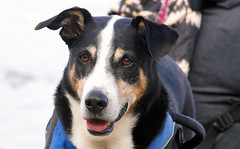
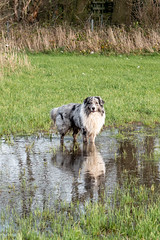
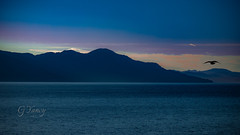
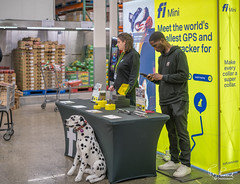
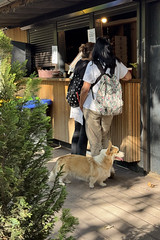

Displayed 5 thumbnails from /content/downloaded_images


In [13]:
# Cell 5: Preview thumbnails
import base64
from IPython.display import display, HTML

def preview_images(folder, max_preview=20, thumb_height=140):
    files = sorted(Path(folder).glob('*'))
    files = files[:max_preview]
    if not files:
        print("No images found to preview.")
        return

    html = ''
    for p in files:
        try:
            with open(p, "rb") as f:
                data = f.read()
                data_url = "data:image/jpeg;base64," + base64.b64encode(data).decode()
                html += (
                    f'<div style="display:inline-block;margin:6px;text-align:center;">'
                    f'<img src="{data_url}" style="height:{thumb_height}px;"><br>'
                    f'{p.name}</div>'
                )
        except Exception as e:
            print(f"Error showing {p}: {e}")

    display(HTML(html))
    print(f"Displayed {len(files)} thumbnails from {folder}")

preview_images(SAVE_DIR, max_preview=20)
